In [3]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import seaborn as sns

In [4]:
# A → B → C → D
k1_seq = 2.0    # A → B
k2_seq = 1.5    # B → C
k3_seq = 1.0    # C → D

# A → B → D и A → B → C → D
k1_hyb = 1.8    # A → B
k2_hyb = 0.7    # B → D
k3_hyb = 0.5    # B → C
k4_hyb = 0.9    # C → D

time_step = 0.1
time_steps = np.arange(0, 2.0, time_step)   
n_measurements = len(time_steps)
n_samples_per_reaction = 2000
total_samples = 2 * n_samples_per_reaction

def generate_initial_concentrations():
    A = np.random.uniform(10, 100)
    return A, 0.0, 0.0, 0.0

# Реакция 1: A → B → C → D (последовательная)
def reaction1_system(t, A, B, C, D, k1, k2, k3):
    dA_dt = -k1 * A
    dB_dt = k1 * A - k2 * B
    dC_dt = k2 * B - k3 * C
    dD_dt = k3 * C
    return dA_dt, dB_dt, dC_dt, dD_dt

# Реакция 2: A → B → D и A → B → C → D (гибридная)
def reaction2_system(t, A, B, C, D, k1, k2, k3, k4):
    dA_dt = -k1 * A
    dB_dt = k1 * A - k2 * B - k3 * B
    dC_dt = k3 * B - k4 * C
    dD_dt = k2 * B + k4 * C
    return dA_dt, dB_dt, dC_dt, dD_dt

def solve_ode(system_func, initial_conditions, rate_constants, time_steps):
    A0, B0, C0, D0 = initial_conditions
    concentrations = [(A0, B0, C0, D0)]

    for i in range(1, len(time_steps)):
        dt = time_steps[i] - time_steps[i-1]
        A_prev, B_prev, C_prev, D_prev = concentrations[-1]

        dA, dB, dC, dD = system_func(
            time_steps[i-1],
            A_prev, B_prev, C_prev, D_prev,
            *rate_constants
        )

        A_new = max(0, A_prev + dA * dt)
        B_new = max(0, B_prev + dB * dt)
        C_new = max(0, C_prev + dC * dt)
        D_new = max(0, D_prev + dD * dt)

        concentrations.append((A_new, B_new, C_new, D_new))

    return concentrations

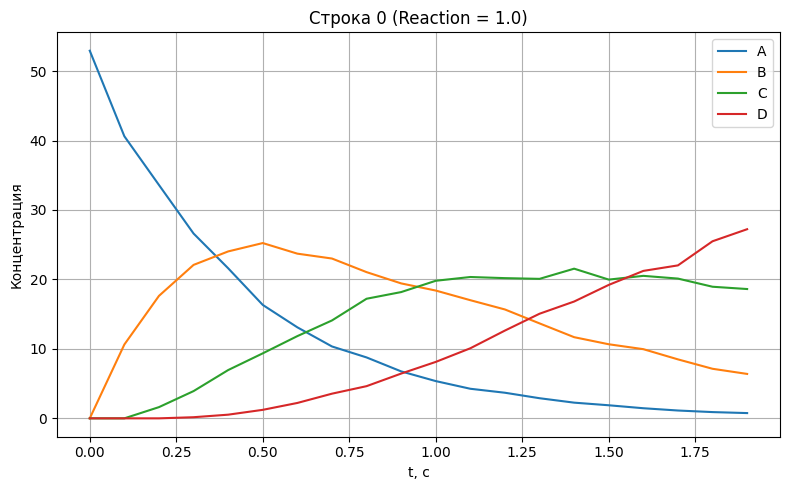

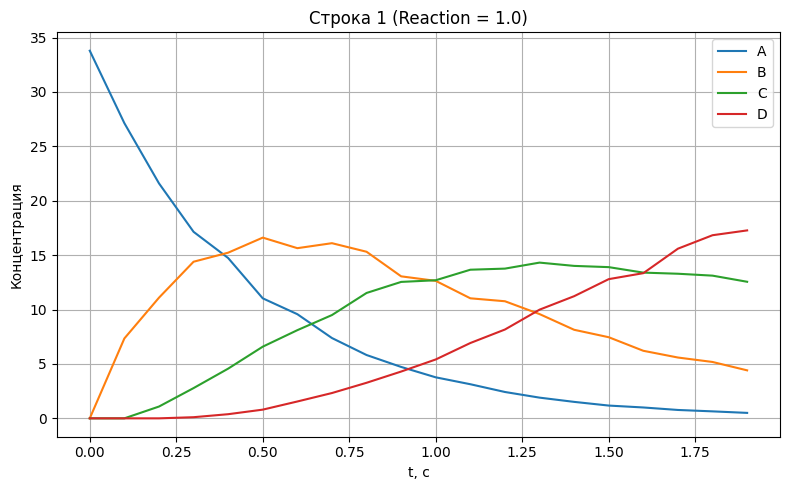

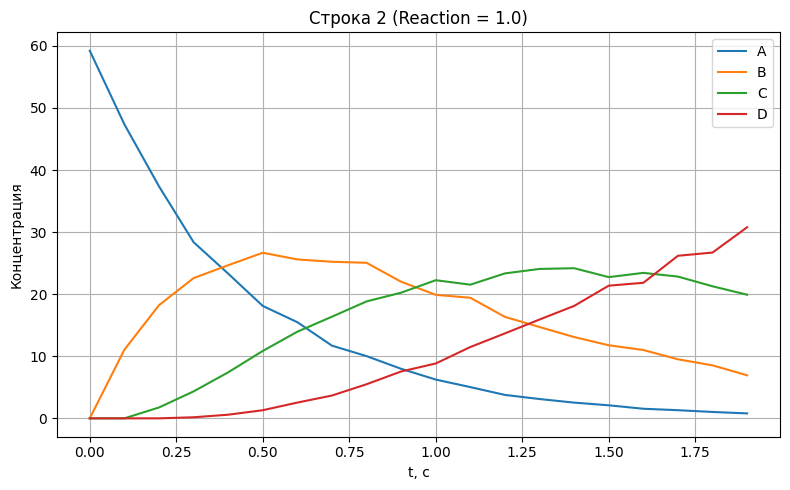

In [5]:
time_step = 0.1
time_steps = np.arange(0, 2.0, time_step)   # 20 точек: t = 0..1.9
n_measurements = len(time_steps)

df = pd.read_csv('data.csv')

df_first3 = df.iloc[:3]

for idx, row in df_first3.iterrows():
    # вытаскиваем временные ряды по каждому компоненту
    A = row[[f'A{i}' for i in range(1, n_measurements + 1)]].values
    B = row[[f'B{i}' for i in range(1, n_measurements + 1)]].values
    C = row[[f'C{i}' for i in range(1, n_measurements + 1)]].values
    D = row[[f'D{i}' for i in range(1, n_measurements + 1)]].values
    reaction_class = row['Reaction']

    plt.figure(figsize=(8, 5))
    plt.plot(time_steps, A, label='A')
    plt.plot(time_steps, B, label='B')
    plt.plot(time_steps, C, label='C')
    plt.plot(time_steps, D, label='D')

    plt.title(f'Строка {idx} (Reaction = {reaction_class})')
    plt.xlabel('t, с')
    plt.ylabel('Концентрация')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


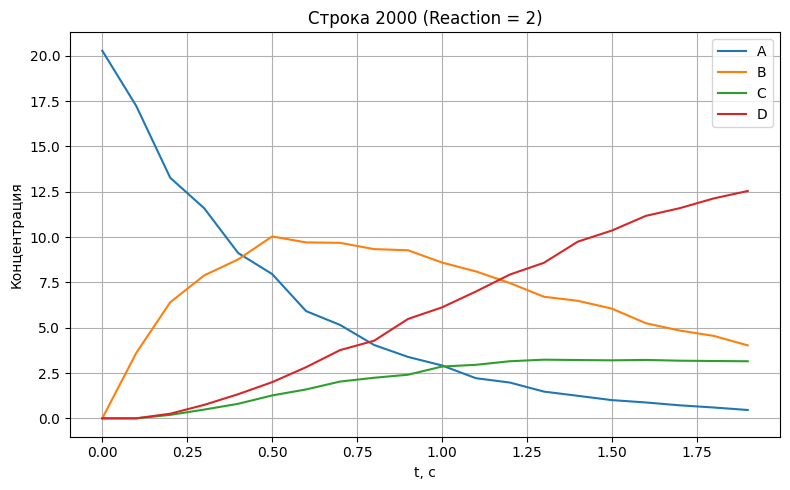

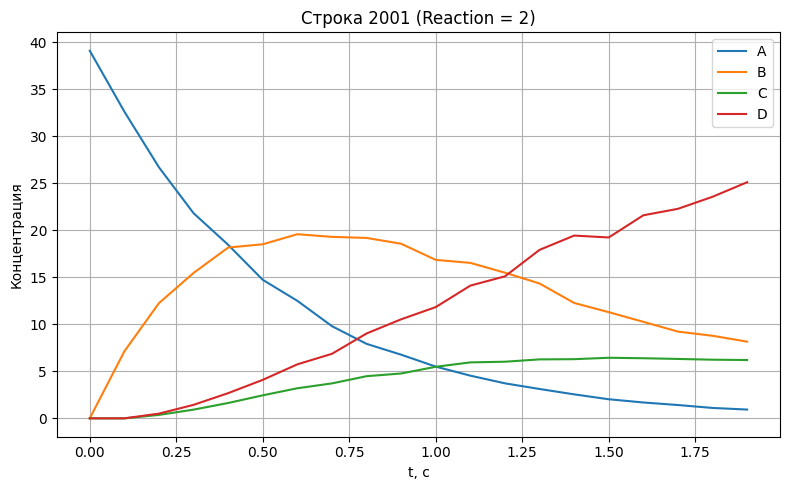

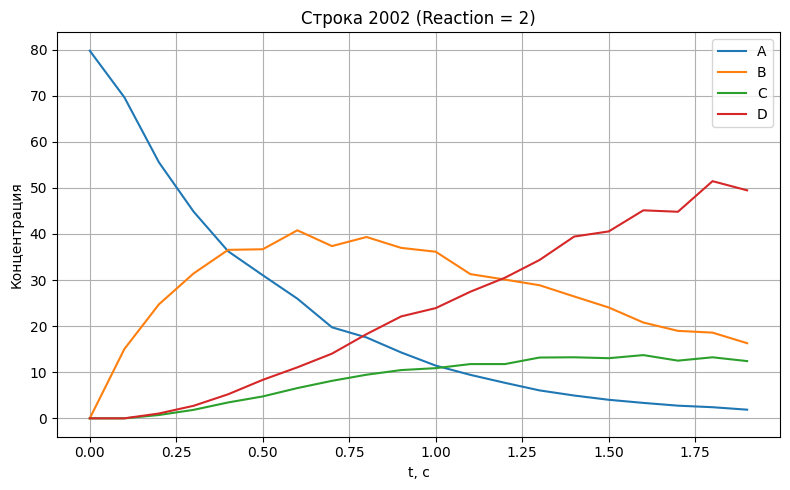

In [6]:
# === параметры времени (как при генерации данных) ===
time_step = 0.1
time_steps = np.arange(0, 2.0, time_step)   # 20 точек: t = 0..1.9
n_measurements = len(time_steps)

# === читаем CSV ===
df = pd.read_csv('data.csv')

# фильтруем только реакцию 2 и берём первые 3 строки
df_reac2_first3 = df[df['Reaction'] == 2].iloc[:3]

for idx, row in df_reac2_first3.iterrows():
    # вытаскиваем временные ряды по каждому компоненту
    A = row[[f'A{i}' for i in range(1, n_measurements + 1)]].values
    B = row[[f'B{i}' for i in range(1, n_measurements + 1)]].values
    C = row[[f'C{i}' for i in range(1, n_measurements + 1)]].values
    D = row[[f'D{i}' for i in range(1, n_measurements + 1)]].values

    plt.figure(figsize=(8, 5))
    plt.plot(time_steps, A, label='A')
    plt.plot(time_steps, B, label='B')
    plt.plot(time_steps, C, label='C')
    plt.plot(time_steps, D, label='D')

    plt.title(f'Строка {idx} (Reaction = 2)')
    plt.xlabel('t, с')
    plt.ylabel('Концентрация')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [7]:
dataset = pd.read_csv('data.csv')

X = dataset.drop('Reaction', axis=1)
y = dataset['Reaction']

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

single_layer_mlp = MLPClassifier(
    hidden_layer_sizes=(),    
    activation='logistic',     
    random_state=42
)

single_layer_mlp.fit(X_train, y_train)

y_pred_single = single_layer_mlp.predict(X_test)
accuracy_single = accuracy_score(y_test, y_pred_single)

print(f"Точность однослойного перцептрона: {accuracy_single:.2f}")

multi_layer_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='logistic',
    random_state=42
)

multi_layer_mlp.fit(X_train, y_train)

y_pred_multi = multi_layer_mlp.predict(X_test)
accuracy_multi = accuracy_score(y_test, y_pred_multi)

print(f"\nТочность многослойного перцептрона: {accuracy_multi:.2f}")


Точность однослойного перцептрона: 1.00

Точность многослойного перцептрона: 1.00


In [8]:
def generate_trajectory(A0, reaction_type):
    if reaction_type == 1:
        conc = solve_ode(
            reaction1_system,
            (A0, 0.0, 0.0, 0.0),
            (k1_seq, k2_seq, k3_seq),
            time_steps
        )
    elif reaction_type == 2:
        conc = solve_ode(
            reaction2_system,
            (A0, 0.0, 0.0, 0.0),
            (k1_hyb, k2_hyb, k3_hyb, k4_hyb),
            time_steps
        )
    else:
        raise ValueError("reaction_type должен быть 1 или 2")

    A_list, B_list, C_list, D_list = [], [], [], []
    for A, B, C, D in conc:
        A_list.append(A)
        B_list.append(B)
        C_list.append(C)
        D_list.append(D)

    features = A_list + B_list + C_list + D_list 
    return np.array(features).reshape(1, -1)

def test_manual(A0_list):
    for A0 in A0_list:
        print(f"\nA0 = {A0}")

        # истинная реакция 1
        x1 = generate_trajectory(A0, reaction_type=1)
        x1_scaled = scaler.transform(x1)
        pred1_s = single_layer_mlp.predict(x1_scaled)[0]
        prob1_s = single_layer_mlp.predict_proba(x1_scaled)[0]

        pred1_m = multi_layer_mlp.predict(x1_scaled)[0]
        prob1_m = multi_layer_mlp.predict_proba(x1_scaled)[0]

        # истинная реакция 2
        x2 = generate_trajectory(A0, reaction_type=2)
        x2_scaled = scaler.transform(x2)
        pred2_s = single_layer_mlp.predict(x2_scaled)[0]
        prob2_s = single_layer_mlp.predict_proba(x2_scaled)[0]

        pred2_m = multi_layer_mlp.predict(x2_scaled)[0]
        prob2_m = multi_layer_mlp.predict_proba(x2_scaled)[0]

        prob1_s_r = np.round(prob1_s, 3)
        prob2_s_r = np.round(prob2_s, 3)
        prob1_m_r = np.round(prob1_m, 3)
        prob2_m_r = np.round(prob2_m, 3)

        print("Однослойный перцептрон:")
        print("Истинный класс 1, предсказание:", pred1_s, ", вероятности:", prob1_s_r)
        print("Истинный класс 2, предсказание:", pred2_s, ", вероятности:", prob2_s_r)
        print("Многослойный перцептрон:")
        print("Истинный класс 1, предсказание:", pred1_m, ", вероятности:", prob1_m_r)
        print("Истинный класс 2, предсказание:", pred2_m, ", вероятности:", prob2_m_r)

test_manual([15, 25, 35])



A0 = 15
Однослойный перцептрон:
Истинный класс 1, предсказание: 1 , вероятности: [0.943 0.057]
Истинный класс 2, предсказание: 2 , вероятности: [0.063 0.937]
Многослойный перцептрон:
Истинный класс 1, предсказание: 1 , вероятности: [0.995 0.005]
Истинный класс 2, предсказание: 2 , вероятности: [0.005 0.995]

A0 = 25
Однослойный перцептрон:
Истинный класс 1, предсказание: 1 , вероятности: [0.99 0.01]
Истинный класс 2, предсказание: 2 , вероятности: [0.01 0.99]
Многослойный перцептрон:
Истинный класс 1, предсказание: 1 , вероятности: [0.998 0.002]
Истинный класс 2, предсказание: 2 , вероятности: [0.002 0.998]

A0 = 35
Однослойный перцептрон:
Истинный класс 1, предсказание: 1 , вероятности: [0.998 0.002]
Истинный класс 2, предсказание: 2 , вероятности: [0.002 0.998]
Многослойный перцептрон:
Истинный класс 1, предсказание: 1 , вероятности: [0.998 0.002]
Истинный класс 2, предсказание: 2 , вероятности: [0.002 0.998]


c:\Users\dasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\dasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\dasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\dasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\dasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: U